<a href="https://colab.research.google.com/github/viaamanda/Machine-Learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [205]:
import pandas as pd
import pandas as dataframe
import string
import nltk
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import collections
import sys
import os
import numpy
import seaborn as sns
import csv
from collections import OrderedDict
from nltk.tokenize import word_tokenize
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from pylab import figure, axes, pie, title, show
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [219]:
github_csv_url = 'https://raw.githubusercontent.com/prlputriih/machine_learning/refs/heads/main/mybca_reviews.csv' # Example: make sure this is a RAW GitHub CSV link, not a GitHub page link

try:
    # Ensure pandas is imported (e.g., in an earlier cell: import pandas as pd)
    df_github = pd.read_csv(github_csv_url)
    print("CSV loaded successfully from GitHub!")
    display(df_github.head())
except NameError as e:
    print(f"Error: {e}. Please ensure 'import pandas as pd' has been executed.")
except Exception as e:
    print(f"Error loading CSV from GitHub: {e}")
    print("Please ensure the URL is a direct raw link to the CSV file (e.g., it starts with raw.githubusercontent.com).")

CSV loaded successfully from GitHub!


,rating,review
0,1,servernya tolong di benerin ini transaksi gua ...
1,1,TF seabank ke bca ga masuk masuk udah dua Minggu
2,1,ngebug terussss
3,1,"parahhhh, gagal terima otp padahal pulsa utama..."
4,1,jelek bener gangguan mulu


In [220]:
df_github = df_github.drop(columns=['rating'])
display(df_github.head())

,review
0,servernya tolong di benerin ini transaksi gua ...
1,TF seabank ke bca ga masuk masuk udah dua Minggu
2,ngebug terussss
3,"parahhhh, gagal terima otp padahal pulsa utama..."
4,jelek bener gangguan mulu


### Cleaning

In [221]:
print(df_github.isnull().sum())

review    0
dtype: int64


In [222]:
print("\nPersentase Missing Values:")
print((df_github.isnull().sum() / len(df_github)) * 100)


Persentase Missing Values:
review   0.000000
dtype: float64


In [223]:
print(f"Number of duplicate reviews before cleaning: {df_github.duplicated(subset=['review']).sum()}")
df_github.drop_duplicates(subset=['review'], inplace=True)
print(f"Number of duplicate reviews after cleaning: {df_github.duplicated(subset=['review']).sum()}")
print(f"DataFrame shape after removing duplicates: {df_github.shape}")

Number of duplicate reviews before cleaning: 19
Number of duplicate reviews after cleaning: 0
DataFrame shape after removing duplicates: (2589, 1)


In [224]:
# Mengubah angka menjadi teks
angka_dict = {
    '0': 'nol',
    '1': 'satu',
    '2': 'dua',
    '3': 'tiga',
    '4': 'empat',
    '5': 'lima',
    '6': 'enam',
    '7': 'tujuh',
    '8': 'delapan',
    '9': 'sembilan'
}

def angka_ke_huruf(text):

    text = str(text)

    hasil = ''

    for char in text:
        if char in angka_dict:
            hasil += ' ' + angka_dict[char] + ' '
        else:
            hasil += char

    return hasil

df_github['angka_text'] = df_github['review'].apply(angka_ke_huruf)

In [225]:
import re

def cleaning_text(text):

    text = str(text)

    # Menggabungkan kata yang dipisah titik
    text = re.sub(r'(\w)\.(\w)', r'\1\2', text)

    # Mengubah strip menjadi spasi
    text = re.sub(r'(\w)-(\w)', r'\1 \2', text)

    # Menghapus URL
    text = re.sub(r'http\S+', '', text)

    # Menghapus punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Menghapus huruf berulang
    text = re.sub(r'(.)\1+', r'\1', text)

    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan cleaning
df_github['cleaning'] = df_github['review'].apply(cleaning_text)

display(df_github[['review', 'cleaning']].head())

,review,cleaning
0,servernya tolong di benerin ini transaksi gua ...,servernya tolong di benerin ini transaksi gua ...
1,TF seabank ke bca ga masuk masuk udah dua Minggu,TF seabank ke bca ga masuk masuk udah dua Mingu
2,ngebug terussss,ngebug terus
3,"parahhhh, gagal terima otp padahal pulsa utama...",parah gagal terima otp padahal pulsa utama uda...
4,jelek bener gangguan mulu,jelek bener ganguan mulu


### Case Folding

In [226]:
df_github['lowercase'] = df_github['cleaning'].str.lower()

display(df_github[['lowercase']].head())

,lowercase
0,servernya tolong di benerin ini transaksi gua ...
1,tf seabank ke bca ga masuk masuk udah dua mingu
2,ngebug terus
3,parah gagal terima otp padahal pulsa utama uda...
4,jelek bener ganguan mulu


### Normalize

In [227]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [228]:
kamus_normalisasi = {

    # Kata Ganti & Entitas
    'gua': 'saya',
    'gue': 'saya',
    'gw': 'saya',
    'aku': 'saya',
    'aq': 'saya',
    'ak': 'saya',
    'user': 'pengguna',

    'bcaku': 'mybca',
    'my bca': 'mybca',
    'bca mobile': 'mybca',
    'mbca': 'mybca',

    'costumer': 'pelanggan',
    'customer': 'pelanggan',
    'cs': 'customer service',

    # Update & Error
    'update': 'perbarui',
    'up': 'perbarui',
    'updt': 'perbarui',

    'error': 'kesalahan',
    'err': 'kesalahan',
    'eror': 'kesalahan',

    # Sistem & Teknis
    'biometrix': 'biometri',
    'biometrik': 'biometri',

    'maintenance': 'perbaikan',
    'maint': 'perbaikan',
    'maintn': 'perbaikan',

    'servernya': 'server',

    # Telepon & Komunikasi
    'call': 'telepon',
    'telp': 'telepon',
    'telpon': 'telepon',

    # Ekspresi
    'adduh': 'aduh',
    'aduuh': 'aduh',
    'aduhh': 'aduh',
    'duh': 'aduh',

    # Login & Akses
    'log in': 'masuk',
    'login': 'masuk',

    'ahir': 'akhir',
    'aktip': 'aktif',

    # Istilah Aplikasi & Bank
    'apk': 'aplikasi',
    'app': 'aplikasi',
    'aps': 'aplikasi',
    'apknya': 'aplikasi',

    'mbanking': 'mobile banking',
    'ebanking': 'mobile banking',
    'm banking': 'mobile banking',

    'tf': 'transfer',
    'trf': 'transfer',

    'rek': 'rekening',

    'finasial': 'finansial',
    'poto': 'foto',
    'develover': 'developer',

    'op': 'otp',

    # Negasi
    'ga': 'tidak',
    'gak': 'tidak',
    'ngga': 'tidak',
    'gk': 'tidak',
    'g': 'tidak',
    'tdk': 'tidak',
    'tida': 'tidak',
    'nda': 'tidak',
    'ndak': 'tidak',

    'gada': 'tidak ada',
    'gamasuk': 'tidak masuk',

    'blm': 'belum',

    # Intensifier
    'bet': 'sangat',
    'bgt': 'sangat',
    'banget': 'sangat',
    'bener': 'sangat',
    'parah': 'sangat',

    # Typo & Slang
    'timbang': 'banding',

    'urgent': 'desak',

    'negri': 'negeri',

    'nmr': 'nomor',
    'nomer': 'nomor',

    'riber': 'rumit',
    'ribet': 'rumit',
    'ribett': 'rumit',
    'repot': 'rumit',

    'benerin': 'perbaiki',
    'nyalahin': 'menyalahkan',
    'bermasalh': 'bermasalah',

    'telkoel': 'telkomsel',
    'telko': 'telkomsel',

    'yg': 'yang',

    'si': 'sih',

    'woi': 'hei',
    'woy': 'hei',

    'udah': 'sudah',
    'udh': 'sudah',
    'uda': 'sudah',
    'dah': 'sudah',

    'sebelumnyauda': 'sebelumnya sudah',

    'jd': 'jadi',

    'trs': 'terus',
    'trus': 'terus',
    'mulu': 'terus',

    'sm': 'sama',
    'dr': 'dari',
    'utk': 'untuk',

    'kayak': 'seperti',

    'gmn': 'bagaimana',
    'gimana': 'bagaimana',
    'gimna': 'bagaimana',
    'gimanasih': 'bagaimana sih',

    'klo': 'kalau',

    'aja': 'saja',

    'dlm': 'dalam',

    'bikin': 'membuat',

    'krn': 'karena',

    'dgn': 'dengan',

    'lg': 'lagi',
    'lgi': 'lagi',

    'tp': 'tapi',

    'mau': 'akan',

    'tau': 'tahu',

    'sempet': 'sempat',

    'milih': 'memilih',

    'ngetik': 'mengetik',

    'ngabisin': 'menghabiskan',

    'berjamjam': 'berjam jam',

    'nungguin': 'menunggu',
    'nunggu': 'menunggu',

    'mala': 'malah',

    'bgs': 'bagus',

    'tambahin': 'tambahkan',

    'ko': 'kok',
    'koq': 'kok',

    'emang': 'memang',

    'kesini': 'ke sini',

    'bs': 'bisa',

    'aktifin': 'aktifkan',
    'ngaktifin': 'mengaktifkan',

    'matiin': 'matikan',

    'cm': 'cuma',

    'lgs': 'langsung',

    'y': 'ya',

    'knpa': 'kenapa',

    'kmaren': 'kemarin',

    'tetep': 'tetap',
    'ttp': 'tetap',

    'kesedot': 'tersedot',

    'jls': 'jelas',
    'jlsh': 'jelas',

    'lelet': 'lambat',

    'hr': 'hari',

    'pake': 'pakai',

    'prihal': 'perihal',

    'baharu': 'baru',

    'lot': 'slot',
    'lotnya': 'slot',

    # Verifikasi & Sistem
    'verivikaisnya': 'verifikasi',
    'verivikasi': 'verifikasi',
    'verifikasinya': 'verifikasi',

    # Kata Berimbuhan
    'aplikasinya': 'aplikasi',

    'prosesnya': 'proses',

    'fiturnya': 'fitur',

    'updatenya': 'perbarui',

    'akunnya': 'akun',

    'loadingnya': 'memuat',

    'otpnya': 'kode otp',

    'loginnya': 'masuk',

    'baharu':'baru',

    'baharunya': 'baru',

    'mbankingnya': 'mobile banking',

    # Normalize
  'abiss': 'habis',
  'aahh': '',
  'adduuh': 'aduh',
  'abisin': 'habiskan'
}

In [229]:
def normalisasi(text):

    kata_kata = text.split()

    hasil = []

    for kata in kata_kata:

        if kata in kamus_normalisasi:
            hasil.append(kamus_normalisasi[kata])
        else:
            hasil.append(kata)

    return ' '.join(hasil)

df_github['normalisasi'] = df_github['lowercase'].apply(normalisasi)

display(df_github[['lowercase', 'normalisasi']].head())

,lowercase,normalisasi
0,servernya tolong di benerin ini transaksi gua ...,server tolong di perbaiki ini transaksi saya k...
1,tf seabank ke bca ga masuk masuk udah dua mingu,transfer seabank ke bca tidak masuk masuk suda...
2,ngebug terus,ngebug terus
3,parah gagal terima otp padahal pulsa utama uda...,sangat gagal terima otp padahal pulsa utama su...
4,jelek bener ganguan mulu,jelek sangat ganguan terus


### Tokenizing

In [230]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [236]:
from nltk.tokenize import word_tokenize

# Tokenizing
df_github['tokenizing'] = df_github['normalisasi'].apply(word_tokenize)

# Menampilkan hasil
display(df_github[['normalisasi', 'tokenizing']].head())

,normalisasi,tokenizing
0,server tolong di perbaiki ini transaksi saya k...,"[server, tolong, di, perbaiki, ini, transaksi,..."
1,transfer seabank ke bca tidak masuk masuk suda...,"[transfer, seabank, ke, bca, tidak, masuk, mas..."
2,ngebug terus,"[ngebug, terus]"
3,sangat gagal terima otp padahal pulsa utama su...,"[sangat, gagal, terima, otp, padahal, pulsa, u..."
4,jelek sangat ganguan terus,"[jelek, sangat, ganguan, terus]"


### Filtering

In [237]:
# Membaca file stopword
with open('stopwords.txt', 'r', encoding='utf-8') as file:
    stopwords_custom = file.read().splitlines()

# Melihat isi stopword
print(stopwords_custom[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [238]:
def filtering(tokens):

    hasil = []

    for kata in tokens:
        if kata not in stopwords_custom:
            hasil.append(kata)

    return hasil

# Terapkan filtering
df_github['filtering'] = df_github['tokenizing'].apply(filtering)

# Tampilkan hasil
display(df_github[['tokenizing', 'filtering']].head())

,tokenizing,filtering
0,"[server, tolong, di, perbaiki, ini, transaksi,...","[server, tolong, perbaiki, transaksi, proses]"
1,"[transfer, seabank, ke, bca, tidak, masuk, mas...","[transfer, seabank, bca, masuk, masuk, mingu]"
2,"[ngebug, terus]",[ngebug]
3,"[sangat, gagal, terima, otp, padahal, pulsa, u...","[gagal, terima, otp, pulsa, utama, tersedot, m..."
4,"[jelek, sangat, ganguan, terus]","[jelek, ganguan]"


### Stemming Teks


In [239]:
# Membuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):

    hasil = []

    for kata in tokens:
        stem = stemmer.stem(kata)
        hasil.append(stem)

    return hasil

In [240]:
df_github['stemming'] = df_github['filtering'].apply(stemming)

# Menampilkan hasil
display(df_github[['filtering', 'stemming']].head())

,filtering,stemming
0,"[server, tolong, perbaiki, transaksi, proses]","[server, tolong, baik, transaksi, proses]"
1,"[transfer, seabank, bca, masuk, masuk, mingu]","[transfer, seabank, bca, masuk, masuk, mingu]"
2,[ngebug],[ngebug]
3,"[gagal, terima, otp, pulsa, utama, tersedot, m...","[gagal, terima, otp, pulsa, utama, sedot, sala..."
4,"[jelek, ganguan]","[jelek, ganguan]"


In [241]:
df_github['stemming_join'] = df_github['stemming'].apply(lambda x: ' '.join(x))

display(df_github[['stemming', 'stemming_join']].head())

,stemming,stemming_join
0,"[server, tolong, baik, transaksi, proses]",server tolong baik transaksi proses
1,"[transfer, seabank, bca, masuk, masuk, mingu]",transfer seabank bca masuk masuk mingu
2,[ngebug],ngebug
3,"[gagal, terima, otp, pulsa, utama, sedot, sala...",gagal terima otp pulsa utama sedot salah telko...
4,"[jelek, ganguan]",jelek ganguan


### TF-IDF (Term Frequency-Inverse Document Frequency)

In [242]:
from collections import Counter
import pandas as pd

# Gabungkan semua kata dari kolom hasil preprocessing
all_words = ' '.join(df_github['stemming_join']).split()

# Hitung frekuensi kata
word_counts = Counter(all_words)

# Ubah ke DataFrame
df_kata = pd.DataFrame(word_counts.items(), columns=['Kata', 'Jumlah'])

# Urutkan dari yang paling sering muncul
df_kata = df_kata.sort_values(by='Jumlah', ascending=False)

# Tampilkan
print(df_kata)

# Kalau mau 20 kata teratas
print(df_kata.head(20))

                Kata  Jumlah
20          aplikasi    1036
74              baru     872
238              lot     721
8              masuk     683
7                bca     651
...              ...     ...
1845     customerkrn       1
1877        gapernah       1
1879  sendirisblmnya       1
1880    lancartolong       1
1839   updategiliran       1

[3454 rows x 2 columns]
           Kata  Jumlah
20     aplikasi    1036
74         baru     872
238         lot     721
8         masuk     683
7           bca     651
37         buka     442
2          baik     317
1        tolong     313
113       pakai     294
17        salah     270
52        mybca     266
3     transaksi     265
46        susah     242
84         kode     235
59   verifikasi     208
11        gagal     207
79         kali     192
21           my     185
53          pas     182
415          hp     169


In [255]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.8,
    token_pattern=r'(?u)\b\w+\b'
)

In [254]:
print("Jumlah total kata unik:", len(feature_names))
print("Daftar semua kata unik:")
print(feature_names)

Jumlah total kata unik: 3366
Daftar semua kata unik:
['00' '01' '02' ... 'zaman' 'zamrud' 'zih']


In [246]:
# Membuat objek TF-IDF
tfidf = TfidfVectorizer()

# Transformasi TF-IDF
X_tfidf = tfidf.fit_transform(df_github['stemming_join'])

# Melihat ukuran matrix
print(X_tfidf.shape)

(2589, 3441)


In [247]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b"
)

X_tfidf = tfidf.fit_transform(df_github['stemming_join'])

print(X_tfidf.toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [256]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# TF-IDF
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b"
)

# Transform text
X_tfidf = tfidf.fit_transform(df_github['stemming_join'])

# Ubah ke DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray())

# Tampilkan
display(tfidf_df.head())

,0,1,2,3,4,5,6,7,8,9,...,3444,3445,3446,3447,3448,3449,3450,3451,3452,3453
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Feature Selection menggunakan Chi-squared


In [258]:
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np

# Definisikan fitur (X) dari DataFrame TF-IDF
X = tfidf_df

y_dummy = np.random.randint(0, 2, size=len(df_github['stemming_join']))

# Inisialisasi SelectKBest dengan chi2 statistic
# Anda bisa menyesuaikan `k` untuk memilih sejumlah fitur terbaik (misalnya k=1000)
selector = SelectKBest(chi2, k=1000)

# Lakukan seleksi fitur
X_new = selector.fit_transform(X, y_dummy)

# Dapatkan indeks fitur yang terpilih
selected_feature_indices = selector.get_support(indices=True)

# Dapatkan nama fitur yang terpilih
selected_feature_names = X.columns[selected_feature_indices]

# Dapatkan skor chi2 dan p-value untuk setiap fitur
chi2_scores = selector.scores_
p_values = selector.pvalues_

# Buat DataFrame untuk menampilkan skor dan p-value
feature_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi2_scores,
    'P_Value': p_values
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("Bentuk matriks fitur setelah seleksi:", X_new.shape)


print("\nContoh Fitur yang Terpilih (k=%s):" % selector.k)
print(selected_feature_names[:20])

Bentuk matriks fitur setelah seleksi: (2589, 1000)

Contoh Fitur yang Terpilih (k=1000):
Index([0, 4, 18, 20, 26, 35, 40, 42, 44, 45, 54, 56, 59, 60, 67, 73, 74, 75,
       76, 80],
      dtype='int64')


In [260]:
from sklearn.feature_selection import chi2
import pandas as pd
import numpy as np

# TF-IDF
X = X_tfidf

# Contoh label dummy
# Ganti jika punya label asli
y = np.random.randint(0, 2, size=X.shape[0]) # Corrected: ensure y has the same number of samples as X

# Hitung chi-square
chi_scores, p_values = chi2(X, y)

# Buat DataFrame
chi_df = pd.DataFrame({
    'Kata': tfidf.get_feature_names_out(),
    'Chi_Square': chi_scores,
    'P_Value': p_values
})

# Urutkan dari nilai terbesar
chi_df = chi_df.sort_values(
    by='Chi_Square',
    ascending=False
)

# Tampilkan
display(chi_df.head(20))

,Kata,Chi_Square,P_Value
3189,tlp,3.815629,0.050777
3323,updet,3.156621,0.075620
3011,sy,2.657991,0.103031
53,akses,2.573227,0.108686
3084,telepon,2.525595,0.112012
986,ganguan,2.270889,0.131824
1631,lanjut,2.237850,0.134668
1394,kemaren,2.226641,0.135648
1299,kacau,2.207070,0.137379
3371,video,2.126083,0.144810


### Word Cloud

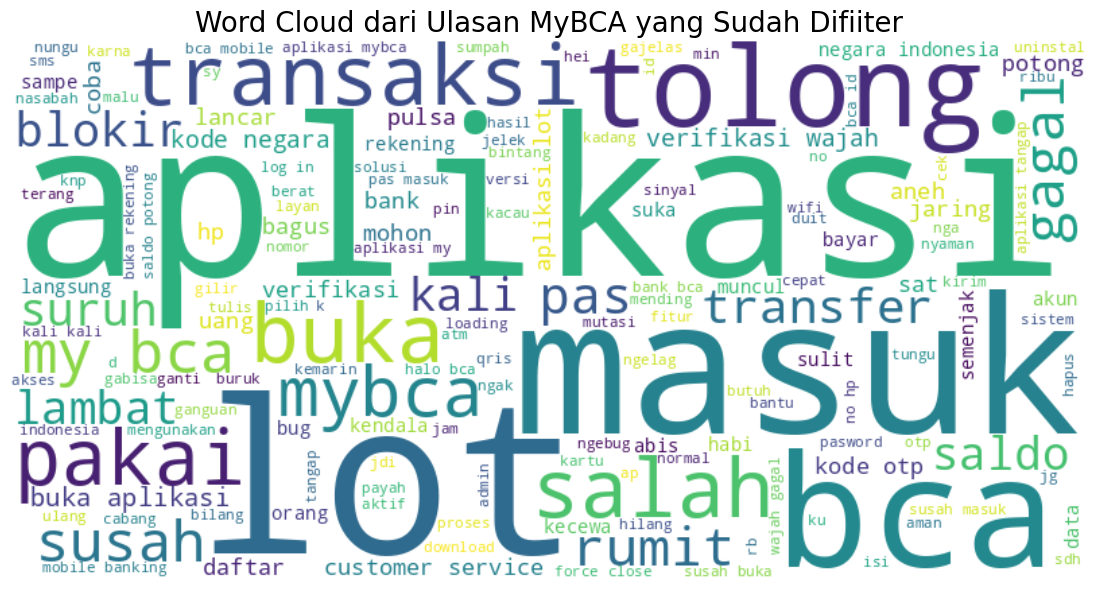

In [262]:
all_filtered_text = ' '.join(df_github['stemming_join'])

# Buat objek WordCloud
wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white',
                      stopwords=all_stopwords,
                      min_font_size=10).generate(all_filtered_text)

# Tampilkan WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu
plt.title('Word Cloud dari Ulasan MyBCA yang Sudah Difiiter', fontsize=20)
plt.show()

### Sentimen

In [263]:
# Membaca kamus kata positif
with open('sentimen positif.txt', 'r', encoding='utf-8') as file:
    positive_words = file.read().splitlines()

# Melihat isi kamus positif
print(positive_words[:20])

['a+', 'acungan jempol', 'adaptif', 'adil', 'afinitas', 'afirmasi', 'agilely', 'agung', 'ahli', 'ahlinya', 'ajaib', 'aklamasi', 'akomodatif', 'akurat', 'alam mimpi', 'alhamdulillah', 'allahu akbar', 'altruistis', 'aman', 'amanah']


In [264]:
# Membaca kamus kata negatif
with open('sentimen negatif.txt', 'r', encoding='utf-8') as file:
    negative_words = file.read().splitlines()

# Melihat isi kamus negatif
print(negative_words[:20])

['abnormal', 'absurd', 'acak', 'acak-acakan', 'acuh', 'acuh tak acuh', 'adiktif', 'adil', 'agresi', 'agresif', 'agresor', 'aib', 'air terjun', 'akurat', 'alarm', 'alasan', 'alat permainan', 'alergi', 'alergik', 'amat ketakutan']


In [265]:
def sentiment_score(tokens):

    positif = 0
    negatif = 0

    for word in tokens:

        if word in positive_words:
            positif += 1

        elif word in negative_words:
            negatif += 1

    return positif, negatif

In [266]:
df_github[['positif', 'negatif']] = df_github['stemming'].apply(
    lambda x: pd.Series(sentiment_score(x))
)

display(df_github[['stemming', 'positif', 'negatif']].head())

,stemming,positif,negatif
0,"[server, tolong, baik, transaksi, proses]",1,0
1,"[transfer, seabank, bca, masuk, masuk, mingu]",0,0
2,[ngebug],0,0
3,"[gagal, terima, otp, pulsa, utama, sedot, sala...",2,6
4,"[jelek, ganguan]",0,1


In [267]:
def sentiment_label(row):

    if row['positif'] > row['negatif']:
        return 'positif'

    elif row['negatif'] > row['positif']:
        return 'negatif'

    else:
        return 'netral'

In [268]:
df_github['sentimen'] = df_github.apply(
    sentiment_label,
    axis=1
)

display(df_github[['stemming', 'positif', 'negatif', 'sentimen']].head())

,stemming,positif,negatif,sentimen
0,"[server, tolong, baik, transaksi, proses]",1,0,positif
1,"[transfer, seabank, bca, masuk, masuk, mingu]",0,0,netral
2,[ngebug],0,0,netral
3,"[gagal, terima, otp, pulsa, utama, sedot, sala...",2,6,negatif
4,"[jelek, ganguan]",0,1,negatif
